# HR Analytics Employee Attrition Dashboard

# Day 3 – Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore employee demographics, salary distribution, job satisfaction, and relationships among variables through visualizations.

### Tasks

- Load the cleaned dataset
- Analyze target variable distribution
- Explore numerical features
- Explore categorical features
- Detect outliers
- Analyze feature correlations
- Summarize key findings

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/hr_cleaned.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Employee Attrition Distribution

This visualization shows the proportion of employees who stayed versus those who left the organization.

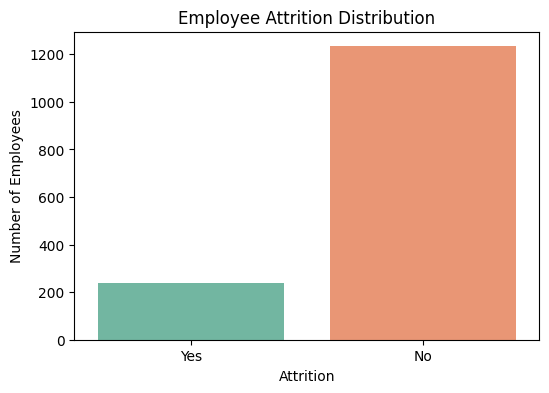

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition",
    hue="Attrition",
    palette="Set2",
    legend=False
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [4]:
attrition_percent = (
    df["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

attrition_percent

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### Business Insight

- Approximately 16% of employees have left the organization.
- Around 84% remain with the company.
- Employee retention is generally good, but attrition analysis is required to understand the reasons behind employee exits.

## Age Distribution

Understanding employee age distribution helps identify workforce demographics.

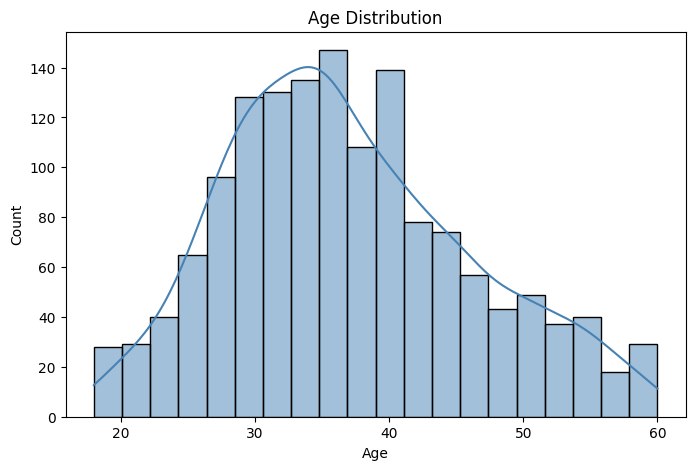

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")

plt.show()

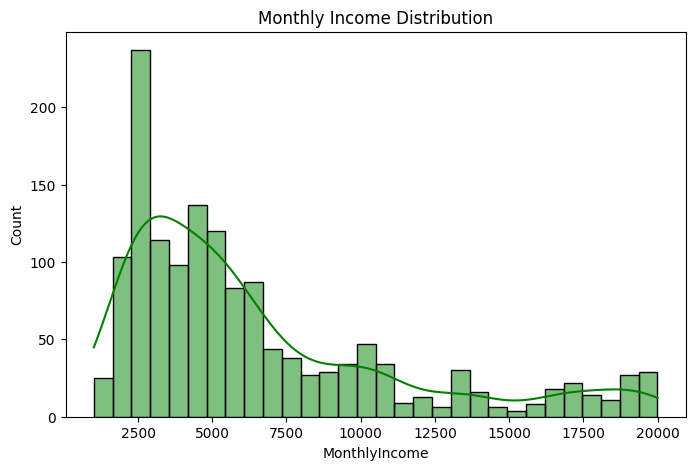

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True,
    color="green"
)

plt.title("Monthly Income Distribution")

plt.show()

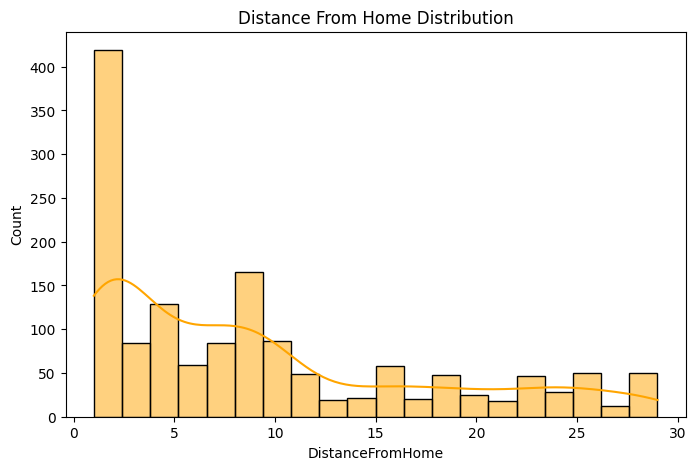

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="DistanceFromHome",
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Distance From Home Distribution")

plt.show()

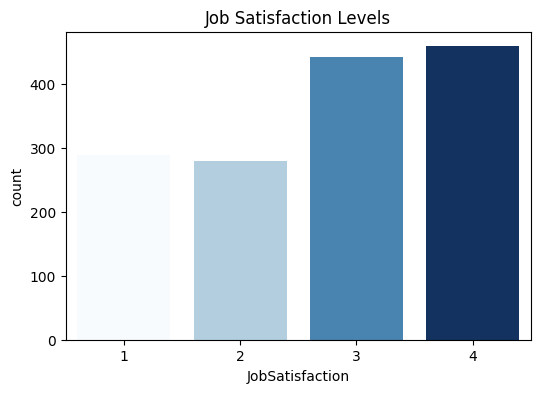

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="JobSatisfaction",
    palette="Blues",
    legend=False
)

plt.title("Job Satisfaction Levels")

plt.show()

## Outlier Detection

Boxplots help identify extreme values in numerical features.

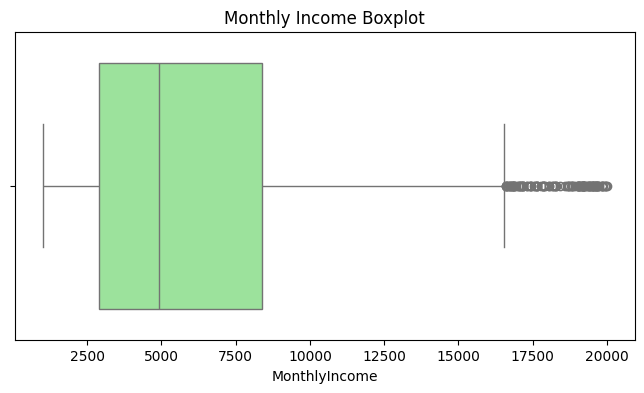

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["MonthlyIncome"],
    color="lightgreen"
)

plt.title("Monthly Income Boxplot")

plt.show()

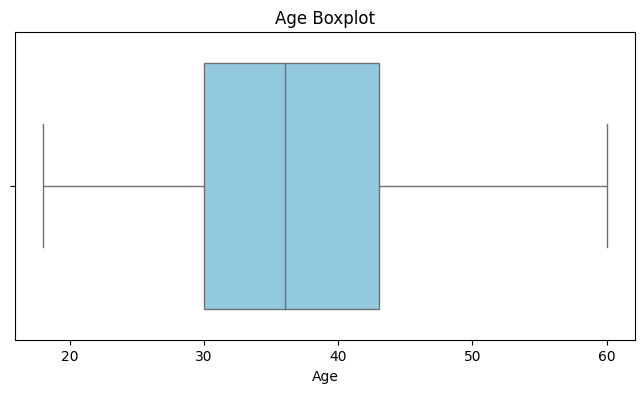

In [10]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Age"],
    color="skyblue"
)

plt.title("Age Boxplot")

plt.show()

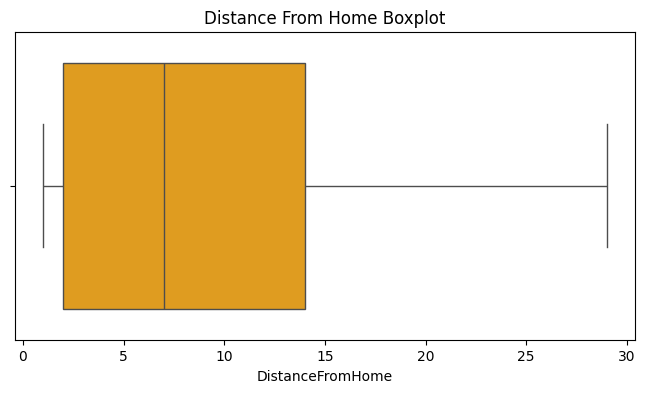

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["DistanceFromHome"],
    color="orange"
)

plt.title("Distance From Home Boxplot")

plt.show()

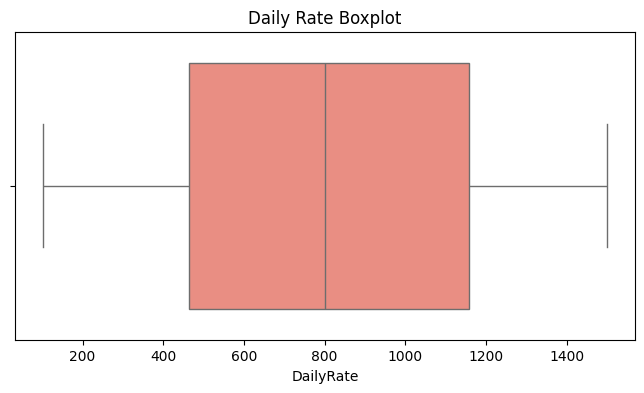

In [12]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["DailyRate"],
    color="salmon"
)

plt.title("Daily Rate Boxplot")

plt.show()

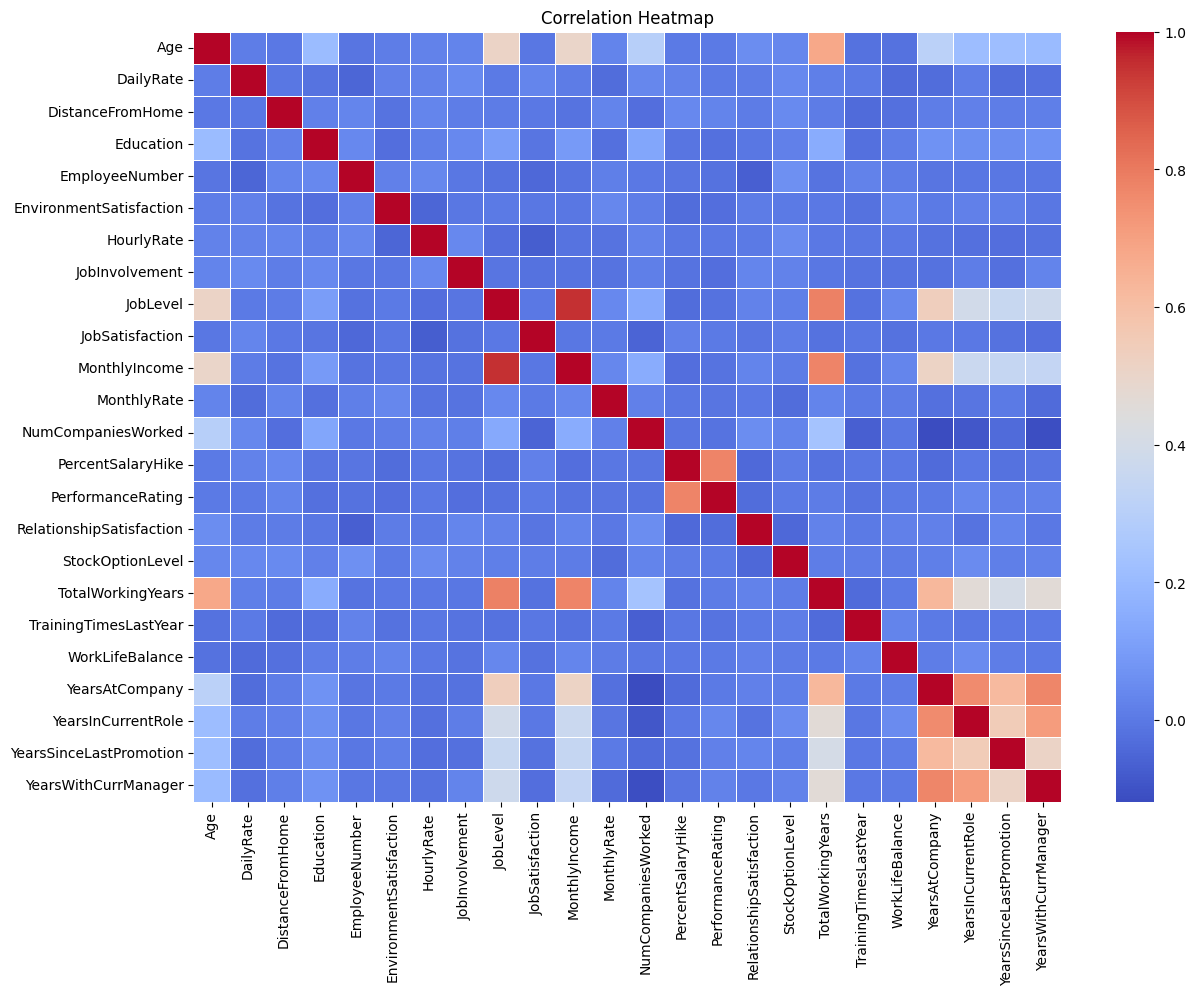

In [13]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numerical_cols].drop(
    columns=["EmployeeCount", "StandardHours"],
    errors="ignore"
)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
corr = corr_df.corr()

corr["MonthlyIncome"].sort_values(ascending=False)

MonthlyIncome               1.000000
JobLevel                    0.950300
TotalWorkingYears           0.772893
YearsAtCompany              0.514285
Age                         0.497855
YearsInCurrentRole          0.363818
YearsSinceLastPromotion     0.344978
YearsWithCurrManager        0.344079
NumCompaniesWorked          0.149515
Education                   0.094961
MonthlyRate                 0.034814
WorkLifeBalance             0.030683
RelationshipSatisfaction    0.025873
DailyRate                   0.007707
StockOptionLevel            0.005408
EnvironmentSatisfaction    -0.006259
JobSatisfaction            -0.007157
EmployeeNumber             -0.014829
JobInvolvement             -0.015271
HourlyRate                 -0.015794
DistanceFromHome           -0.017014
PerformanceRating          -0.017120
TrainingTimesLastYear      -0.021736
PercentSalaryHike          -0.027269
Name: MonthlyIncome, dtype: float64

In [15]:
corr["Age"].sort_values(ascending=False)

Age                         1.000000
TotalWorkingYears           0.680381
JobLevel                    0.509604
MonthlyIncome               0.497855
YearsAtCompany              0.311309
NumCompaniesWorked          0.299635
YearsSinceLastPromotion     0.216513
YearsInCurrentRole          0.212901
Education                   0.208034
YearsWithCurrManager        0.202089
RelationshipSatisfaction    0.053535
StockOptionLevel            0.037510
JobInvolvement              0.029820
MonthlyRate                 0.028051
HourlyRate                  0.024287
DailyRate                   0.010661
EnvironmentSatisfaction     0.010146
PercentSalaryHike           0.003634
PerformanceRating           0.001904
DistanceFromHome           -0.001686
JobSatisfaction            -0.004892
EmployeeNumber             -0.010145
TrainingTimesLastYear      -0.019621
WorkLifeBalance            -0.021490
Name: Age, dtype: float64

# Day 3 Summary

### Key Findings

- Employee attrition is approximately 16%.
- Most employees are between 30 and 40 years old.
- Salary distribution is right-skewed.
- Monthly Income is strongly correlated with Job Level and Total Working Years.
- Outliers are present in salary-related variables but represent valid business observations.
- Most HR variables show weak correlations, indicating that employee attrition is influenced by multiple factors.

### Next Steps

The next notebook will focus on business-oriented exploratory analysis, including attrition by department, job role, overtime, gender, age group, and income band.